# Introduction

This is the basic reproduction experiment for Yao et al., "Dynamic Word Embeddings for Evolving Semantic Discovery".
It is based on the source code provided in their
[GitHub repository](https://github.com/yifan0sun/DynamicWord2Vec)
and aims to simplify the experiment, update it to a modern Python setup, and ultimately validate the findings from the authors.

# Setup

## Imports

In [8]:
!git pull

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 2), reused 6 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 417.93 KiB | 4.22 MiB/s, done.
From https://github.com/MarkusStefan/Semantic-Embedding-Evolution
   7d0c37d..c13f327  feat/transformer -> origin/feat/transformer
Updating 7d0c37d..c13f327
Fast-forward
 notebooks/fine_tuning_experiment.ipynb |  644 +++++++++++++++
 notebooks/reproduction.ipynb           |  144 ++--
 notebooks/transformer.ipynb            | 1410 ++++++++++++++++++++++++++++++++
 3 files changed, 2110 insertions(+), 88 deletions(-)
 create mode 100644 notebooks/fine_tuning_experiment.ipynb
 create mode 100644 notebooks/transformer.ipynb


In [1]:
# file io
import scipy.io as sio

# machine learning
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# analyses and plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [2]:
import os
if os.getcwd() != '/home/jovyan/Semantic-Embedding-Evolution/notebooks':
    os.chdir('Semantic-Embedding-Evolution/notebooks')

## Data setup
The experiment relies on files from the researchers dropbox folder. These files are saved in the data directory first.

In [3]:
%run ../setup/setup.py

Target data directory: /home/jovyan/Semantic-Embedding-Evolution/data
Data seems to be loaded already. Skipping download.


## Static variables

In [4]:
seed = 42
years = range(1990, 2017)
vocab_size = 20936
embeddings_file = "../data/emb_static.mat"
word_id_file = "../data/wordIDHash.csv"
train_path = "../data/pmi_"

## Use GPU if possible

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Setup static embeddings

In [6]:
static_embeddings = sio.loadmat(embeddings_file)["emb"]
static_embeddings = torch.from_numpy(static_embeddings).float()

## Word to id mapping
The PMI (pointwise mutual information) is stored in an indexed form. The wordIdHash table holds the id for each word.

In [9]:
df_word_id = pd.read_csv(word_id_file, header=None, names=["id", "word", "count"])

wordlist = [f"missing_word_idx_{i}" for i in range(vocab_size)]

for _, row in df_word_id.iterrows():
    wordlist[int(row["id"])] = str(row["word"])

word2Id = {word: i for i, word in enumerate(wordlist)}

# Dataset
The authors of the study provide the data in MATLAB files. Each PMI file contains the PMI for the word combinations that occur together. The data is very large, so it is not possible to preload it all. However, for slight performance increases, we can load the dense format of the data to the GPU.

In [10]:
class PMIDataset(Dataset):
    def __init__(self, time_steps, train_path, vocab_size):
        self.time_steps = time_steps
        self.train_path = train_path
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.time_steps)

    def __getitem__(self, idx):
        t_idx = self.time_steps[idx]
        file_path = f"{train_path}{t_idx}.mat"

        pmi = sio.loadmat(file_path)["pmi"]
        pmi = torch.from_numpy(pmi.toarray()).float()

        return t_idx, pmi

In [11]:
dataset = PMIDataset(range(len(years)), train_path, vocab_size)
loader = DataLoader(dataset, batch_size=1)

In [ ]:
# print a couple of samples from the dataset
for i, (t_idx, pmi) in enumerate(loader):
    print(f"Time step index: {t_idx.item()}, PMI matrix shape: {pmi.shape}")
    if i > 2:
        break

Time step index: 0, PMI matrix shape: torch.Size([1, 20936, 20936])
Time step index: 1, PMI matrix shape: torch.Size([1, 20936, 20936])
Time step index: 2, PMI matrix shape: torch.Size([1, 20936, 20936])


In [13]:
print(pmi)

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0067, 0.2410],
         [0.0000, 0.0000, 0.0000,  ..., 0.0067, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.2410, 0.0000, 0.0000]]])


In [19]:
len(wordlist)

20936

# Model
The original study does manual gradient calculation, which is not necessary in the PyTorch framework.
Instead, only the loss is calculated with the same components as in Yao et al.

In [ ]:
class DynamicTransformerModel(nn.Module):
    def __init__(self, n_years, initial_emb, n_head=4, n_layers=2, dropout=0.1, dim_feedforward=200):
        super().__init__()
        self.n_years = n_years
        vocab_size, dim = initial_emb.shape
        
        # Static embedding (learnable initialization)
        self.static_emb = nn.Parameter(initial_emb.clone())
        
        # Positional encoding for years
        self.year_pos_emb = nn.Parameter(torch.zeros(n_years, 1, dim))
        nn.init.normal_(self.year_pos_emb, mean=0, std=0.1)
        
        # Transformer Encoder
        # We use batch_first=False by default in PyTorch Transformer: (S, N, E)
        # S = n_years, N = vocab_size, E = dim
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=n_head, dim_feedforward=dim_feedforward, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Output heads
        self.head_U = nn.Linear(dim, dim)
        self.head_V = nn.Linear(dim, dim)

    def forward(self):
        # Input: (S, N, E) -> (n_years, vocab_size, dim)
        
        # Expand static embeddings: (N, E) -> (1, N, E) -> (S, N, E)
        x = self.static_emb.unsqueeze(0).expand(self.n_years, -1, -1)
        
        # Add positional embeddings: (S, 1, E) -> (S, N, E)
        x = x + self.year_pos_emb
        
        # Transformer
        encoded = self.transformer(x)
        
        # Heads
        U = self.head_U(encoded)
        V = self.head_V(encoded)
        
        return U, V

    @torch.no_grad()
    def get_embeddings(self):
        U, _ = self.forward()
        return U.detach()

    @torch.no_grad()
    def get_drift(self, word_idx):
        U = self.get_embeddings()
        start_vec = U[0, word_idx]
        end_vec = U[-1, word_idx]

        cos_sim = torch.cosine_similarity(start_vec, end_vec, dim=0).item()
        drift_norm = torch.norm(start_vec - end_vec).item()

        return drift_norm, cos_sim


In [23]:
import torch
import torch.nn as nn
import math

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Pre-compute the positional encodings once
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Register as buffer (not a learnable parameter -> Faster)
        self.register_buffer('pe', pe.unsqueeze(1)) # (max_len, 1, d_model)

    def forward(self, x):
        # x: (Seq_Len, Batch, Dim)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class VisualizableBlock(nn.Module):
    """
    A single Transformer block that saves its attention weights.
    Uses Pre-LN (Normalization before usage) for faster convergence.
    """
    def __init__(self, dim, n_head, dim_feedforward, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, n_head, dropout=dropout)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, dim)
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (S, N, E)
        
        # 1. Pre-LN Attention
        x_norm = self.norm1(x)
        # need_weights=True allows us to capture the "Time Travel" map
        attn_out, weights = self.attn(x_norm, x_norm, x_norm, need_weights=True)
        x = x + self.dropout(attn_out)
        
        # 2. Pre-LN FFN
        x_norm = self.norm2(x)
        ffn_out = self.ffn(x_norm)
        x = x + self.dropout(ffn_out)
        
        return x, weights

class DynamicTransformerModel(nn.Module):
    def __init__(self, n_years, initial_emb, n_head=4, n_layers=1, dropout=0.1, dim_feedforward=200):
        super().__init__()
        self.n_years = n_years
        vocab_size, dim = initial_emb.shape
        
        # 1. Static Embeddings
        self.static_emb = nn.Parameter(initial_emb.clone())
        
        # 2. Faster Positional Encoding (Sinusoidal)
        self.pos_encoder = SinusoidalPositionalEncoding(dim, max_len=n_years, dropout=dropout)
        
        # 3. Visualizable Encoder Stack
        # We use a ModuleList to stack layers manually so we can access weights
        self.layers = nn.ModuleList([
            VisualizableBlock(dim, n_head, dim_feedforward, dropout)
            for _ in range(n_layers)
        ])
        
        # 4. Output Heads
        self.head_U = nn.Linear(dim, dim)
        self.head_V = nn.Linear(dim, dim)
        
        # Storage for visualization (Global average attention)
        self.last_attn_weights = None

    def forward(self):
        # Input: (n_years, vocab_size, dim)
        
        # Expand static embeddings: (N, E) -> (S, N, E)
        x = self.static_emb.unsqueeze(0).expand(self.n_years, -1, -1)
        
        # Add Positional Encoding (The "Bias" that speeds up training)
        x = self.pos_encoder(x)
        
        # Pass through layers
        # We only save the weights of the LAST layer for visualization
        for layer in self.layers:
            x, weights = layer(x)
        
        # weights shape: (Batch/Vocab, Year_Query, Year_Key)
        # We average over the vocabulary dimension to get the "Global Time Structure"
        # This is efficient and gives the "General History" view.
        self.last_attn_weights = weights.mean(dim=0).detach().cpu()
        
        # Heads
        U = self.head_U(x)
        V = self.head_V(x)
        
        return U, V

    @torch.no_grad()
    def get_embeddings(self):
        U, _ = self.forward()
        return U.detach()
        
    @torch.no_grad()
    def get_drift(self, word_idx):
        U = self.get_embeddings() # (Years, Vocab, Dim)
        start_vec = U[0, word_idx]
        end_vec = U[-1, word_idx]
        cos_sim = torch.cosine_similarity(start_vec, end_vec, dim=0).item()
        drift_norm = torch.norm(start_vec - end_vec).item()
        return drift_norm, cos_sim

# Training

## Hyperparameters

- **lam**: L2 regularizer penalizing large weights
- **tau**: Penalty for weight differences between years
- **gam**: Penalty for misalignment between U and V
- **emph**: Factor for loss corresponding to words that really cooccured in the PMI data


In [24]:
n_epochs = 25
lam = 1
tau = 0.005
gam = 0.5
emph = 5000
learning_rate = 1e-3
weight_decay = 1e-5
n_head = 5
n_layers = 2
dropout = 0.1

## Training procedure

In [25]:
# Clear cache before training
torch.cuda.empty_cache()

model = DynamicTransformerModel(len(years), static_embeddings, n_head=n_head, n_layers=n_layers, dropout=dropout, dim_feedforward=200).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

for epoch in range(n_epochs):
    model.train()
    
    indices = torch.randperm(len(years))
    epoch_loss = 0
    
    for y_idx in indices:
        # Forward pass
        U_all, V_all = model()
        
        # Get specific year
        U_t = U_all[y_idx]
        V_t = V_all[y_idx]
        
        # Load PMI (Dense CPU tensor)
        _, pmi = dataset[y_idx.item()]
        
        # Calculate reconstruction loss in chunks to save memory
        rec_loss = 0
        chunk_size = 2048 # Adjust based on GPU memory
        
        for i in range(0, vocab_size, chunk_size):
            end = min(i + chunk_size, vocab_size)
            
            # Move chunk to GPU
            pmi_chunk = pmi[i:end].to(device)
            U_chunk = U_t[i:end]
            
            # Predict chunk
            pred_chunk = torch.matmul(U_chunk, V_t.t())
            
            # Loss chunk
            mask_chunk = (pmi_chunk > 0).float()
            weight_chunk = mask_chunk * emph + (1 - mask_chunk)
            rec_loss += torch.sum(weight_chunk * torch.square(pmi_chunk - pred_chunk))
            
            # Cleanup
            del pmi_chunk, pred_chunk, mask_chunk, weight_chunk
        
        # Other losses
        alignment_loss = gam * torch.sum(torch.square(U_t - V_t))

        temporal_loss = 0
        if y_idx > 0:
            temporal_loss = tau * torch.sum(torch.square(U_t - U_all[y_idx - 1]))

        loss = rec_loss + alignment_loss + temporal_loss
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Clear cache occasionally
        # torch.cuda.empty_cache()

    # monitor change of embeddings for reference word 'amazon'
    drift, sim = model.get_drift(word2Id["amazon"])
    print(f"Epoch {epoch} | Loss: {epoch_loss/len(years):.2f} | Drift: {drift:.4f} | Cosine Similarity: {sim:.4f}")

print("Training finished")

Epoch 0 | Loss: 224141295312.59 | Drift: 3.4540 | Cosine Similarity: 0.5676
Epoch 1 | Loss: 111607978818.37 | Drift: 3.0539 | Cosine Similarity: 0.6225
Epoch 2 | Loss: 101375094025.48 | Drift: 2.2668 | Cosine Similarity: 0.7058
Epoch 3 | Loss: 60388243228.44 | Drift: 2.5505 | Cosine Similarity: 0.5147


KeyboardInterrupt: 

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import math

# --- 1. The Fast & Lightweight Model ---
class FastDynamicModel(nn.Module):
    def __init__(self, n_years, initial_emb, n_head=4, n_layers=1, dropout=0.1, dim_feedforward=128):
        super().__init__()
        self.n_years = n_years
        vocab_size, dim = initial_emb.shape
        
        # Learnable embeddings initialized from static Word2Vec
        self.static_emb = nn.Parameter(initial_emb.clone())
        
        # Sinusoidal Positional Encoding (Faster than learnable)
        self.register_buffer('pos_enc', self._create_sinusoidal_emb(n_years, dim))
        
        # Small Transformer (1 layer is often enough for simple drift)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, 
            nhead=n_head, 
            dim_feedforward=dim_feedforward, 
            dropout=dropout,
            batch_first=False,
            norm_first=True # Pre-LN converges faster
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Heads for U (Target) and V (Context) matrices
        self.head_U = nn.Linear(dim, dim)
        self.head_V = nn.Linear(dim, dim)

    def _create_sinusoidal_emb(self, len, dim):
        pe = torch.zeros(len, dim)
        position = torch.arange(0, len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(1) # (S, 1, E)

    def forward(self):
        # 1. Expand static embedding across time: (1, V, D) -> (T, V, D)
        x = self.static_emb.unsqueeze(0).expand(self.n_years, -1, -1)
        
        # 2. Add Position (Broadcasting adds (T, 1, D) to (T, V, D))
        x = x + self.pos_enc
        
        # 3. Transformer Pass
        encoded = self.transformer(x)
        
        return self.head_U(encoded), self.head_V(encoded)

# --- 2. Fast Training Loop ---

def train_fast(model, dataset, word2Id, device, n_epochs=10):
    # Hyperparameters for Speed/Stability
    LEARNING_RATE = 2e-3
    CHUNK_SIZE = 4096 * 2  # Larger chunk = Less python overhead loop
    LAM, TAU, GAM, EMPH = 1.0, 0.5, 0.5, 5000.0 # Standard loss weights
    
    # Optimizer & Scheduler
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LEARNING_RATE, steps_per_epoch=len(dataset), epochs=n_epochs
    )
    scaler = GradScaler() # For Mixed Precision

    # Compile for speed (PyTorch 2.0+)
    try:
        model = torch.compile(model)
        print("Model compiled with torch.compile!")
    except:
        pass

    model.train()
    vocab_size = model.static_emb.shape[0]
    
    print(f"Starting Fast Training on {device}...")
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        
        # Shuffle years to prevent temporal overfitting
        years_indices = torch.randperm(model.n_years)
        
        for step, t in enumerate(years_indices):
            # Load PMI data to GPU (Blocking I/O - ensure disk is fast or preload)
            _, pmi_matrix = dataset[t.item()]
            
            # --- Mixed Precision Context ---
            with autocast():
                # 1. Forward Pass (Get all years)
                U_all, V_all = model()
                
                # 2. Select current year vectors
                U_t = U_all[t] # (Vocab, Dim)
                V_t = V_all[t] # (Vocab, Dim)
                
                # 3. Reconstruction Loss (The Heavy Part)
                # Calculate ||PMI - U*V.T||^2 in chunks to save VRAM but use FP16 for speed
                rec_loss = 0
                for i in range(0, vocab_size, CHUNK_SIZE):
                    end = min(i + CHUNK_SIZE, vocab_size)
                    
                    # Slicing
                    pmi_chunk = pmi_matrix[i:end].to(device, non_blocking=True)
                    U_chunk = U_t[i:end]
                    
                    # Prediction
                    pred_chunk = torch.matmul(U_chunk, V_t.T)
                    
                    # Weighted MSE (EMPH for positive entries)
                    # Optimization: create mask only once or implicitly
                    mask = (pmi_chunk > 0)
                    diff = (pmi_chunk - pred_chunk)
                    
                    # Fast weighted sum
                    # Loss = EMPH * diff^2 (where mask) + 1 * diff^2 (where ~mask)
                    weighted_diff = torch.where(mask, diff * math.sqrt(EMPH), diff)
                    rec_loss += torch.sum(weighted_diff ** 2)

                # 4. Regularization Losses
                align_loss = GAM * torch.sum((U_t - V_t) ** 2)
                
                temp_loss = 0
                if t > 0:
                    # Enforce smoothness with previous year
                    temp_loss = TAU * torch.sum((U_t - U_all[t-1].detach()) ** 2)
                
                total_loss = rec_loss + align_loss + temp_loss

            # --- Backward Pass (Scaled) ---
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(total_loss).backward()
            
            # Gradient Clipping (Unscale first)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            epoch_loss += total_loss.item()

        # Monitoring
        if epoch % 1 == 0:
            # Check drift of a reference word (e.g., 'amazon' or index 100)
            ref_idx = word2Id.get("amazon", 100)
            with torch.no_grad():
                # Quick drift check
                U_now, _ = model()
                drift = torch.norm(U_now[0, ref_idx] - U_now[-1, ref_idx])
            
            print(f"Epoch {epoch+1}/{n_epochs} | Loss: {epoch_loss:.2e} | 'Amazon' Drift: {drift:.4f}")

    return model

model = FastDynamicModel(len(years), static_embeddings, n_head=4, n_layers=1, dropout=0.1, dim_feedforward=128).to(device)
model = train_fast(model, dataset, word2Id, device, n_epochs=15)

AssertionError: embed_dim must be divisible by num_heads

# Output visualization

## Example embedding over time

In [62]:
def plot_word_embedding_trajectory(word, model=model, word2Id=word2Id, years=years, old_meaning=[], new_meaning=[]):
    # get word ids
    word_idx = word2Id[word]
    old_indices = [word2Id[w] for w in old_meaning if w in word2Id]
    new_indices = [word2Id[w] for w in new_meaning if w in word2Id]

    # generate embeddings
    model.eval()
    with torch.no_grad():
        all_U = model.get_embeddings() # (n_years, vocab_size, dim)
        embs = all_U[:, word_idx, :].cpu().numpy()
        old_embs = all_U[0, old_indices, :].cpu().numpy() if old_indices else np.empty((0, embs.shape[1]))
        new_embs = all_U[-1, new_indices, :].cpu().numpy() if new_indices else np.empty((0, embs.shape[1]))

    # combine all embeddings
    all_to_plot = np.vstack([embs, old_embs, new_embs])

    # calculate TSNE
    current_perplexity = min(5, len(all_to_plot) - 1)
    tsne = TSNE(n_components=2, perplexity=current_perplexity, random_state=seed, init="pca")
    Z_all = tsne.fit_transform(all_to_plot)

    # split results
    Z = Z_all[:len(years)]
    Z_old = Z_all[len(years):len(years) + len(old_indices)]
    Z_new = Z_all[len(years) + len(old_indices):]

    # plot
    plt.figure(figsize=(10, 6))
    plt.plot(Z[:, 0], Z[:, 1], linestyle="--", color="gray", alpha=0.5)

    # keyword trajectory
    for i, year in enumerate(years):
        plt.scatter(Z[i, 0], Z[i, 1], color="red", s=100, edgecolors="black")
        plt.text(Z[i, 0] + 0.05, Z[i, 1] + 0.05, f"{year}", fontsize=9)

    # old meaning reference points
    for i, w in enumerate(old_meaning):
        if i < len(Z_old):
            plt.scatter(Z_old[i, 0], Z_old[i, 1], color="green", marker="X", s=150, edgecolors="black")
            plt.text(Z_old[i, 0] + 0.05, Z_old[i, 1] + 0.05, w, color="green", fontweight='bold')

    # new meaning reference points
    for i, w in enumerate(new_meaning):
        if i < len(Z_new):
            plt.scatter(Z_new[i, 0], Z_new[i, 1], color="blue", marker="X", s=150, edgecolors="black")
            plt.text(Z_new[i, 0] + 0.05, Z_new[i, 1] + 0.05, w, color="blue", fontweight='bold')

    plt.title(f"Semantic Drift Trajectory for '{word}' from {years[0]} until {years[-1]}")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

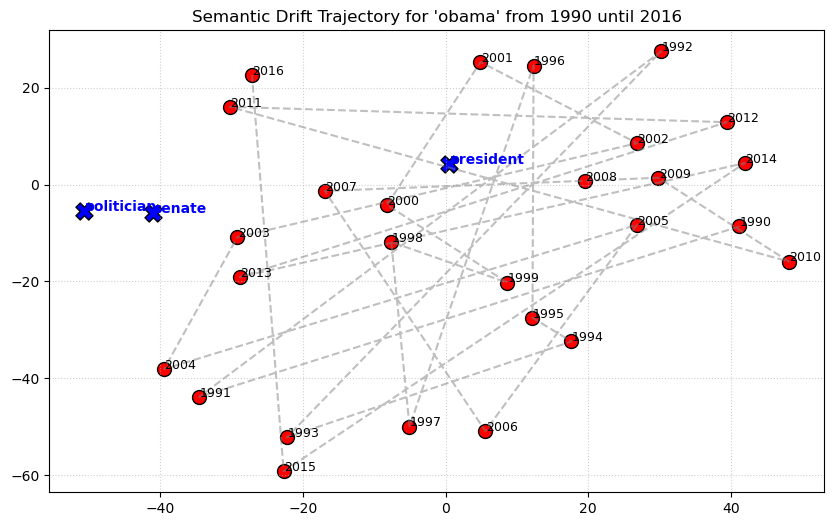

In [63]:
plot_word_embedding_trajectory("obama", new_meaning=["president", "senate", "politician"])

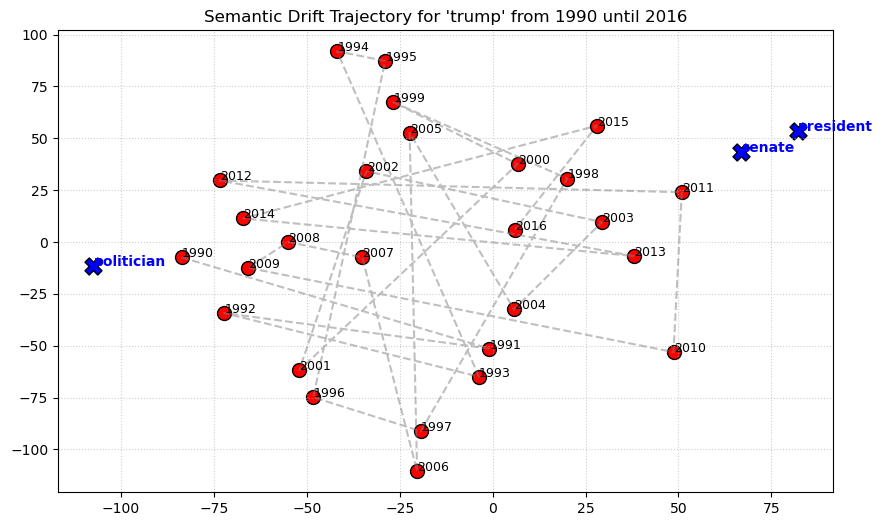

In [64]:
plot_word_embedding_trajectory("trump", new_meaning=["president", "senate", "politician"])

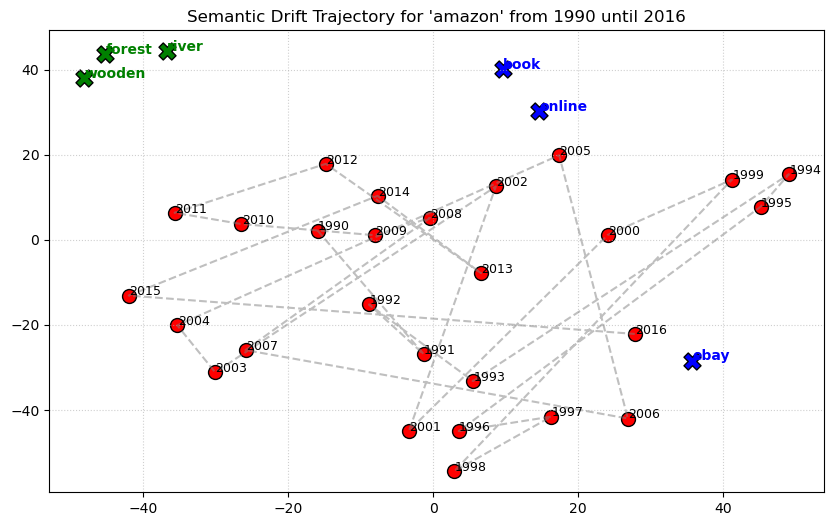

In [65]:
plot_word_embedding_trajectory(
    "amazon",
    old_meaning=["forest", "wooden", "river"],
    new_meaning=["book", "online", "ebay"]
)

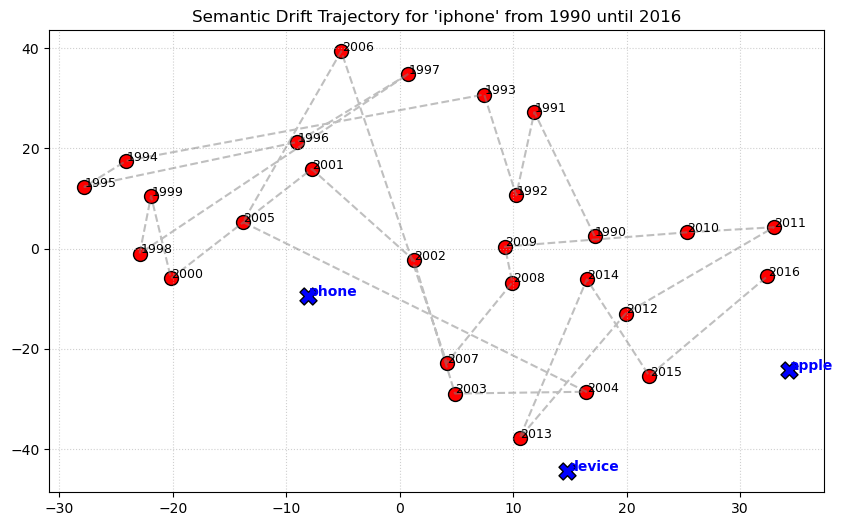

In [66]:
plot_word_embedding_trajectory("iphone", new_meaning=["phone", "device", "apple"])

## Closest words over time

In [67]:
def get_temporal_neighbors(word, model=model, word2Id=word2Id, wordlist=wordlist, years=years, top_n=5):
    word_idx = word2Id[word]
    results = []
    model.eval()

    with torch.no_grad():
        all_U = model.get_embeddings().cpu()

        for i, year in enumerate(years):
            word_embedding = all_U[i]

            # use cosine similarity as measure of semantic closeness
            sims = torch.nn.functional.cosine_similarity(word_embedding[word_idx].unsqueeze(0), word_embedding)

            # take top_n indices
            _, indices = torch.topk(sims, top_n + 2)

            # map to neighbor words
            neighbors = [wordlist[idx] for idx in indices.tolist()
                             if wordlist[idx].lower() != word.lower()][:top_n]

            results.append({"Year": year, "Top Neighbors": ", ".join(neighbors)})

    return pd.DataFrame(results)

In [68]:
get_temporal_neighbors("trump", top_n=5).set_index("Year").T

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
Top Neighbors,"romney, candidates, perot, candidate, palin","romney, candidates, perot, voters, gingrich","romney, perot, candidates, candidate, rubio","romney, candidates, perot, gingrich, voters","perot, romney, candidates, palin, rubio","romney, candidates, perot, palin, candidate","romney, candidates, perot, candidate, voters","romney, candidates, perot, isis, voters","romney, candidates, perot, palin, candidate","romney, candidates, perot, palin, candidate",...,"palin, romney, candidates, perot, santorum","palin, candidates, perot, romney, santorum","romney, candidates, perot, candidate, voters","romney, candidates, perot, candidate, voters","romney, candidates, perot, voters, candidate","romney, candidates, candidate, perot, voters","romney, candidates, perot, palin, rubio","romney, candidates, perot, voters, candidate","romney, candidates, voters, candidate, perot","romney, perot, candidates, candidate, voters"


In [69]:
get_temporal_neighbors("obama", top_n=5).set_index("Year").T

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
Top Neighbors,"clinton, bush, national, campaign, state","clinton, bush, national, campaign, state","clinton, bush, national, state, campaign","clinton, bush, state, national, country","bush, clinton, national, campaign, president","clinton, bush, national, campaign, state","clinton, bush, national, state, president","bush, clinton, state, national, president","bush, clinton, national, state, president","bush, clinton, national, campaign, president",...,"clinton, bush, national, state, campaign","clinton, bush, national, campaign, president","clinton, bush, national, campaign, state","clinton, bush, national, campaign, state","clinton, bush, state, national, campaign","bush, clinton, national, campaign, state","bush, clinton, national, state, president","clinton, bush, national, state, states","clinton, bush, national, state, campaign","clinton, bush, state, national, campaign"
